# 🧠 Brain Tumor MRI Classification — 30 Classes (v2)

**Model:** EfficientNetV2-M (Transfer Learning)
**Dataset:** fernando2rad/brain-tumor-mri-images-30-classes (Kaggle)

---

## 🔧 Thay đổi so với v1
| | v1 | v2 |
|---|---|---|
| IMG_SIZE | 480×480 | **384×384** (nhẹ hơn, ít overfit hơn) |
| Loss | CrossEntropy + class_weight | **Focal Loss** (xử lý imbalance tốt hơn) |
| Augmentation | Nhẹ | **Mạnh hơn** (MixUp, RandomErasing, GridDistortion) |
| Dropout | 0.4 | **0.5** |
| Head | Dense(512) | **Dense(512) → Dense(256)** (thêm 1 lớp) |
| Weight decay | Không | **AdamW + 1e-4** |
| Monitor | val_accuracy | **val_f1_macro** |
| Class weights | Dùng với CE | Không cần (Focal Loss tự xử lý) |

---

## 📋 Mục lục
1. Cài đặt & Import thư viện
2. Tải Dataset từ Kaggle
3. Khám phá & Chuẩn bị dữ liệu
4. Split dữ liệu theo Class (giữ phân phối nhãn)
5. Tạo Data Pipeline (tf.data) — augmentation mạnh
6. Focal Loss + F1 Macro Metric
7. Xây dựng Model EfficientNetV2-M v2
8. Kiểm tra Checkpoint & Resume Training
9. Phase 1 — Train (Freeze Backbone)
10. Phase 2 — Fine-tune (Unfreeze dần)
11. Visualize Learning Curves
12. Đánh giá trên Test Set
13. Visualize Kết quả Dự đoán

---

### ⚠️ Lưu ý quan trọng
- Split theo **class_name** để giữ phân phối nhãn ổn định
- **Focal Loss** tự xử lý imbalance (không cần class_weight riêng)
- Monitor **val_f1_macro** thay vì val_accuracy để chọn best checkpoint
- Phase 2 unfreeze **từng block** từ top xuống, không unfreeze hết cùng lúc

## 1. Cài đặt & Import thư viện

In [1]:
!pip install -q kagglehub scikit-learn 

In [3]:
import os
import re
import glob
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2M
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping,
    ReduceLROnPlateau, CSVLogger, LambdaCallback
)

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import kagglehub
import warnings
warnings.filterwarnings('ignore')

# ── Seed cố định ──
RANDOM_SEED = 32
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ['PYTHONHASHSEED'] = str(RANDOM_SEED)

print('✅ Import xong!')
print(f'TensorFlow version: {tf.__version__}')

✅ Import xong!
TensorFlow version: 2.19.0


In [4]:
gpus = tf.config.list_physical_devices('GPU')
print(f'Số GPU khả dụng: {len(gpus)}')
for i, gpu in enumerate(gpus):
    print(f'  GPU {i}: {gpu.name}')

strategy = tf.distribute.MirroredStrategy()
print(f'\n🚀 Số thiết bị trong strategy: {strategy.num_replicas_in_sync}')

Số GPU khả dụng: 2
  GPU 0: /physical_device:GPU:0
  GPU 1: /physical_device:GPU:1
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')

🚀 Số thiết bị trong strategy: 2


I0000 00:00:1782438747.659506      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782438747.666030      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
# ══════════════════════════════════════
#   CẤU HÌNH TOÀN CỤC (chỉnh ở đây)
# ══════════════════════════════════════

IMG_SIZE      = 384          # ↓ từ 480 → giảm overfitting, tốc độ tốt hơn
BATCH_SIZE    = 56           # 16 per GPU × 2 GPU
NUM_CLASSES   = 30
RANDOM_SEED   = 32

# Split ratio: 70 / 15 / 15 (theo class)
VAL_RATIO     = 0.15
TEST_RATIO    = 0.15

# Train từ đầu sau khi đổi split / pipeline
START_FROM_SCRATCH = False
RESUME_CHECKPOINT = '/kaggle/input/notebooks/dart098/efficientnet-ver-2/checkpoints/epoch_01.weights.h5'
RESUME_EPOCH = 2

# Phase 1: Freeze backbone
PHASE1_EPOCHS = 15           # ↑ từ 10 → cho head ổn định hơn trước khi unfreeze
PHASE1_LR     = 1e-3

# Phase 2: Unfreeze fine-tune (dần dần)
PHASE2_EPOCHS = 30
PHASE2_LR     = 1e-4         # ↑ tăng LR để hội tụ nhanh hơn

# Focal Loss params
FOCAL_GAMMA   = 2.0          # focus vào hard examples
FOCAL_ALPHA   = 0.25         # cân bằng positive/negative

# Thư mục lưu
CKPT_DIR      = '/kaggle/working/checkpoints'
BEST_WEIGHT   = '/kaggle/working/best_weights.weights.h5'
LOG_CSV       = '/kaggle/working/training_log.csv'

os.makedirs(CKPT_DIR, exist_ok=True)
print('✅ Cấu hình xong!')
print(f'  IMG_SIZE    : {IMG_SIZE}×{IMG_SIZE}  (↓ từ 480)')
print(f'  BATCH_SIZE  : {BATCH_SIZE}')
print(f'  NUM_CLASSES : {NUM_CLASSES}')
print(f'  Phase1 LR   : {PHASE1_LR}  | {PHASE1_EPOCHS} epochs')
print(f'  Phase2 LR   : {PHASE2_LR}  | {PHASE2_EPOCHS} epochs')
print(f'  Focal gamma : {FOCAL_GAMMA} | alpha: {FOCAL_ALPHA}')
print(f'  Split       : 70/15/15 theo class')
print(f'  Start fresh : {START_FROM_SCRATCH}')

✅ Cấu hình xong!
  IMG_SIZE    : 384×384  (↓ từ 480)
  BATCH_SIZE  : 56
  NUM_CLASSES : 30
  Phase1 LR   : 0.001  | 15 epochs
  Phase2 LR   : 0.0001  | 30 epochs
  Focal gamma : 2.0 | alpha: 0.25
  Split       : 70/15/15 theo class
  Start fresh : False


## 2. Tải Dataset từ Kaggle

In [6]:
path = kagglehub.dataset_download('fernando2rad/brain-tumor-mri-images-30-classes')
print(f'Dataset path: {path}')

# Liệt kê cấu trúc thư mục
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for f in files[:3]:
            print(f'{subindent}{f}')
        if len(files) > 3:
            print(f'{subindent}... ({len(files)} files total)')

Dataset path: /kaggle/input/datasets/fernando2rad/brain-tumor-mri-images-30-classes
brain-tumor-mri-images-30-classes/
  DATA.json
  Astrocytoma T2/
    T2 - Diffuse astrocytoma frontal , temporal 012.jpg
    T2 - Pilocytic astrocytoma posterior fossa , ventricle 028.jpg
    T2 - Pilocytic astrocytoma ventricle 046.jpg
    ... (281 files total)
  Neurocytoma T1C+/
    T1C+ - Central neurocytoma 048.jpg
    T1C+ - Extraventricular neurocytoma frontal 010.jpg
    T1C+ - Central neurocytoma ventricle 005.jpg
    ... (254 files total)
  Glioma T1/
    T1 - Low grade glioma 004.jpg
    T1 - High grade glioma, NOS grade 4 temporal , basal ganglia 088.jpg
    T1 - Thalamic glioma ventricle , supratentorial 049.jpg
    ... (522 files total)
  Schwannoma T1C+/
    T1C+ - Multicompartmental trigeminal schwannoma middle cranial fossa , temporal 103.jpg
    T1C+ - Trigeminal schwannoma cerebellopontine angle , trigeminal 009.jpg
    T1C+ - Vestibular schwannoma intracanalicular , brainstem 011.jpg

## 3. Khám phá & Chuẩn bị dữ liệu

In [7]:
# ── Thu thập tất cả file ảnh ──
all_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']:
    all_files.extend(glob.glob(os.path.join(path, '**', ext), recursive=True))

print(f'Tổng số file ảnh: {len(all_files):,}')

# ── Tạo DataFrame ──
records = []
for fp in all_files:
    parts = Path(fp).parts
    class_name = parts[-2]   # thư mục cha = tên class
    records.append({'filepath': fp, 'class_name': class_name})

df = pd.DataFrame(records)

# ── Encode label ──
CLASS_NAMES = sorted(df['class_name'].unique().tolist())
class2idx = {c: i for i, c in enumerate(CLASS_NAMES)}
df['label'] = df['class_name'].map(class2idx)

print(f'Số class      : {NUM_CLASSES}')
print(f'Số ảnh unique : {len(df):,}')
print(f'Số class thực : {df["class_name"].nunique():,}')
print(f'\nTop class phân phối:')
print(df['class_name'].value_counts())

Tổng số file ảnh: 11,300
Số class      : 30
Số ảnh unique : 11,300
Số class thực : 30

Top class phân phối:
class_name
Meningioma T1C+            977
Other T1C+                 756
Meningioma T1              636
Schwannoma T1C+            564
Glioma T1C+                549
Glioma T1                  522
Meningioma T2              458
Astrocytoma T1C+           441
Normal T1                  415
Other T1                   412
Glioma T2                  405
Astrocytoma T1             396
Normal T2                  379
Ependymoma T1C+            374
Other T2                   365
Schwannoma T1              363
Ependymoma T2              350
Ependymoma T1              313
Schwannoma T2              309
Hemangiopericytoma T1C+    307
Astrocytoma T2             281
Normal T1C+                264
Neurocytoma T1C+           254
Oligodendroglioma T1       221
Oligodendroglioma T1C+     192
Neurocytoma T1             190
Hemangiopericytoma T1      178
Neurocytoma T2             174
Oligodendrogl

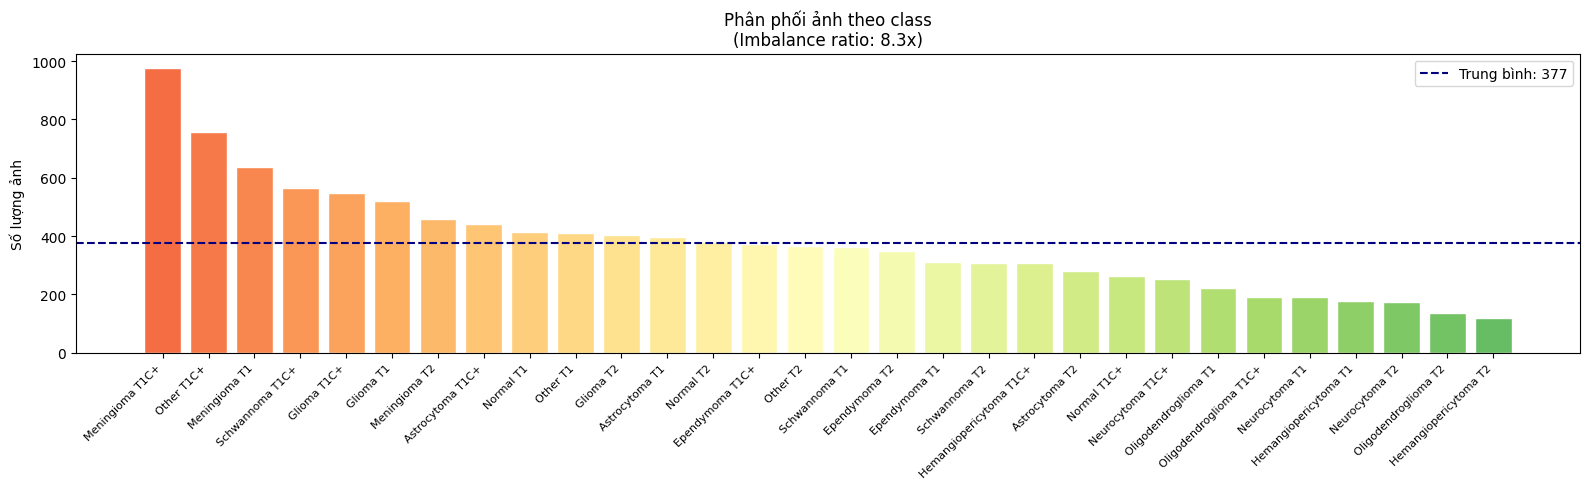


Min samples/class: 118 (Hemangiopericytoma T2)
Max samples/class: 977 (Meningioma T1C+)
Imbalance ratio  : 8.3x


In [8]:
# ── Visualize phân phối class ──
fig, ax = plt.subplots(figsize=(16, 5))
counts = df['class_name'].value_counts()
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(counts)))
ax.bar(counts.index, counts.values, color=colors, edgecolor='white')
ax.set_xticklabels(counts.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Số lượng ảnh')
ax.set_title('Phân phối ảnh theo class\n(Imbalance ratio: {:.1f}x)'.format(
    counts.max() / counts.min()))
ax.axhline(counts.mean(), color='navy', linestyle='--', label=f'Trung bình: {counts.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nMin samples/class: {counts.min()} ({counts.idxmin()})')
print(f'Max samples/class: {counts.max()} ({counts.idxmax()})')
print(f'Imbalance ratio  : {counts.max()/counts.min():.1f}x')

## 4. Split dữ liệu theo Class (giữ phân phối nhãn)

In [9]:
# ── Split theo class label để giữ phân phối nhãn ổn định ──
# Mỗi ảnh là một sample; split stratified theo class
train_idx, valtest_idx = train_test_split(
    df.index,
    test_size=VAL_RATIO + TEST_RATIO,
    stratify=df['label'],
    random_state=RANDOM_SEED
)

valtest_df = df.loc[valtest_idx].copy()
val_idx, test_idx = train_test_split(
    valtest_df.index,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=valtest_df['label'],
    random_state=RANDOM_SEED
)

# Kiểm tra không có overlap theo index gốc
assert len(set(train_idx) & set(val_idx)) == 0
assert len(set(train_idx) & set(test_idx)) == 0
assert len(set(val_idx) & set(test_idx)) == 0

train_df = df.loc[train_idx].reset_index(drop=True)
val_df   = df.loc[val_idx].reset_index(drop=True)
test_df  = df.loc[test_idx].reset_index(drop=True)

print('✅ Split xong (theo class_name):')
print(f'  Train: {len(train_df):>6,} ảnh')
print(f'  Val  : {len(val_df):>6,} ảnh')
print(f'  Test : {len(test_df):>6,} ảnh')
print(f'\n  Tỉ lệ thực tế: {len(train_df)/len(df)*100:.1f}% / {len(val_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%')
print('\n✅ Không có overlap giữa các split!')


✅ Split xong (theo class_name):
  Train:  7,910 ảnh
  Val  :  1,695 ảnh
  Test :  1,695 ảnh

  Tỉ lệ thực tế: 70.0% / 15.0% / 15.0%

✅ Không có overlap giữa các split!


## 5. Tạo Data Pipeline (tf.data) — Augmentation mạnh

**Thay đổi so với v1:**
- Thêm `RandomErasing` (xóa ngẫu nhiên vùng ảnh)
- Thêm `GridDistortion` (biến dạng lưới — tốt cho medical imaging)
- Thêm `MixUp` (trộn 2 ảnh + nhãn)
- Tăng cường rotation, zoom, brightness/contrast
- `MixUp` chỉ áp dụng cho **train set**

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

# ── Hàm đọc & resize ảnh ──
def load_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32)   # [0, 255] — EfficientNetV2M tự normalize
    return img, label

def _rotate(img, angle):
    from tensorflow.keras.preprocessing.image import apply_affine_transform
    result = apply_affine_transform(img.numpy(), theta=float(angle.numpy()) * 57.3)
    return tf.cast(result, tf.float32)
    
# ── Augmentation mạnh cho train ──
def augment_train(img, label, use_color_jitter=True):
    # Flip
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)

    # ✅ Bọc trong py_function → chạy eager, được dùng .numpy()
    angle = tf.random.uniform([], -0.26, 0.26)
    img = tf.py_function(func=_rotate, inp=[img, angle], Tout=tf.float32)
    img.set_shape([IMG_SIZE, IMG_SIZE, 3])  # ⚠️ Bắt buộc set lại shape

    # Zoom (crop + resize)
    scale = tf.random.uniform([], 0.80, 1.0)
    h = tf.cast(IMG_SIZE * scale, tf.int32)
    w = tf.cast(IMG_SIZE * scale, tf.int32)
    img = tf.image.random_crop(img, [h, w, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])

    # Brightness & Contrast
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, 0.9, 1.1)

    # Saturation & Hue: chỉ dùng cho phase 1
    if use_color_jitter:
        img = tf.image.random_saturation(img, 0.9, 1.1)
        img = tf.image.random_hue(img, 0.03)

    # Random Erasing
    def random_erasing(img):
        erase_h = tf.random.uniform([], 20, IMG_SIZE // 5, dtype=tf.int32)
        erase_w = tf.random.uniform([], 20, IMG_SIZE // 5, dtype=tf.int32)
        top  = tf.random.uniform([], 0, IMG_SIZE - erase_h, dtype=tf.int32)
        left = tf.random.uniform([], 0, IMG_SIZE - erase_w, dtype=tf.int32)
        mask = tf.ones([erase_h, erase_w, 3], dtype=tf.float32) * 128.0
        padding = [[top, IMG_SIZE - top - erase_h],
                   [left, IMG_SIZE - left - erase_w],
                   [0, 0]]
        mask_full = tf.pad(mask, padding)
        erase_mask = tf.ones([IMG_SIZE, IMG_SIZE, 3], dtype=tf.float32)
        erase_mask = erase_mask - tf.cast(mask_full > 0, tf.float32)
        return img * erase_mask + mask_full

    img = tf.cond(
        tf.random.uniform([]) > 0.5,
        lambda: random_erasing(img),
        lambda: img
    )

    img = tf.clip_by_value(img, 0.0, 255.0)
    return img, label


# ── MixUp ──
def mixup_batch(images, labels, alpha=0.1):
    """Apply MixUp augmentation trên 1 batch."""
    batch_size = tf.shape(images)[0]
    
    lam = tf.random.uniform([batch_size], 0.0, 1.0)
    lam = tf.maximum(lam, 1 - lam)
    lam = tf.reshape(lam, [batch_size, 1, 1, 1])

    idx      = tf.random.shuffle(tf.range(batch_size))
    mixed_x  = lam * images + (1 - lam) * tf.gather(images, idx)
    lam_flat = tf.reshape(lam, [batch_size])

    y1 = tf.one_hot(labels, NUM_CLASSES)
    y2 = tf.one_hot(tf.gather(labels, idx), NUM_CLASSES)
    mixed_y  = tf.reshape(lam_flat, [batch_size, 1]) * y1 + \
               tf.reshape(1 - lam_flat, [batch_size, 1]) * y2

    mixed_x = tf.cast(mixed_x, tf.float32)
    return mixed_x, mixed_y


# ── Build datasets ──
def build_dataset(data_df, training=False, mixup=False, color_aug=True):
    filepaths = data_df['filepath'].values
    labels    = data_df['label'].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if training:
        ds = ds.shuffle(len(data_df), seed=RANDOM_SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(
            lambda x, y: augment_train(x, y, use_color_jitter=color_aug),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE, drop_remainder=training)

    if training and mixup:
        ds = ds.map(
            lambda x, y: mixup_batch(x, y, alpha=0.1),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = build_dataset(train_df, training=True,  mixup=True,  color_aug=True)
train_ds_p2 = build_dataset(train_df, training=True, mixup=False, color_aug=False)
val_ds   = build_dataset(val_df,   training=False, mixup=False)
test_ds  = build_dataset(test_df,  training=False, mixup=False)

print('✅ Dataset pipeline xong!')
print(f'  Train batches   : {len(train_ds)}')
print(f'  Train P2 batches: {len(train_ds_p2)}')
print(f'  Val   batches    : {len(val_ds)}')
print(f'  Test  batches    : {len(test_ds)}')
print(f'\n  Phase 1 aug : flip, rotate, zoom, color jitter, erasing, MixUp')
print(f'  Phase 2 aug : flip, rotate, zoom, brightness/contrast nhẹ, erasing')

✅ Dataset pipeline xong!
  Train batches   : 141
  Train P2 batches: 141
  Val   batches    : 31
  Test  batches    : 31

  Phase 1 aug : flip, rotate, zoom, color jitter, erasing, MixUp
  Phase 2 aug : flip, rotate, zoom, brightness/contrast nhẹ, erasing


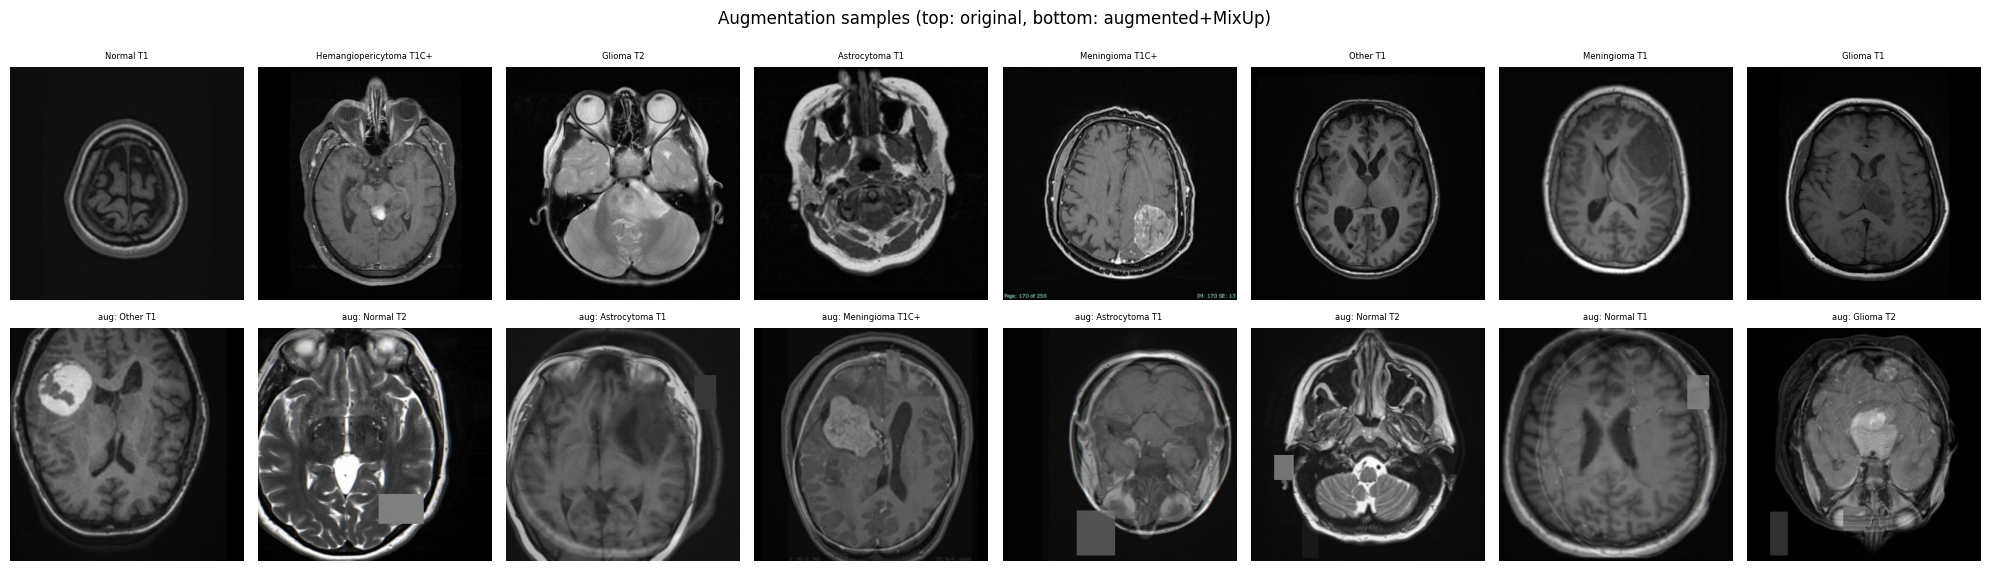

In [11]:
# ── Visualize augmented samples ──
fig, axes = plt.subplots(2, 8, figsize=(20, 6))

# Ảnh gốc (val_ds)
for i, (imgs, lbls) in enumerate(val_ds.take(1)):
    for j in range(8):
        ax = axes[0, j]
        ax.imshow(imgs[j].numpy().astype(np.uint8))
        ax.set_title(CLASS_NAMES[lbls[j].numpy()], fontsize=6)
        ax.axis('off')

# Ảnh augmented (train_ds — sau MixUp labels là soft)
for i, (imgs, lbls) in enumerate(train_ds.take(1)):
    for j in range(8):
        ax = axes[1, j]
        ax.imshow(tf.cast(imgs[j], tf.uint8).numpy())
        dominant = CLASS_NAMES[np.argmax(lbls[j].numpy())]
        ax.set_title(f'aug: {dominant}', fontsize=6)
        ax.axis('off')

axes[0, 0].set_ylabel('Original', fontsize=9, rotation=0, labelpad=50)
axes[1, 0].set_ylabel('Augmented', fontsize=9, rotation=0, labelpad=45)
plt.suptitle('Augmentation samples (top: original, bottom: augmented+MixUp)', fontsize=12)
plt.tight_layout()
plt.savefig('/kaggle/working/augmentation_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Focal Loss + F1 Macro Metric

**Tại sao Focal Loss?**
- CrossEntropy với class_weight giúp nhưng vẫn bị dominated bởi easy examples
- Focal Loss thêm factor `(1 - p_t)^gamma` — giảm loss của easy examples, tăng focus vào hard/minority examples
- Không cần điều chỉnh class_weight thủ công

**Tại sao monitor F1 Macro?**
- Accuracy dễ bị mislead bởi class đông
- F1 Macro tính trung bình không weighted → phát hiện ngay khi model học kém 1 class nào đó

In [12]:
class FocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss cho multi-class classification.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Hỗ trợ cả hard labels (integer) và soft labels (one-hot / MixUp).
    """
    def __init__(self, gamma=2.0, alpha=0.25, name='focal_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_pred = tf.cast(y_pred, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
    
        # Nếu y_true là hard label → convert one-hot
        if len(y_true.shape) == 1:
            # Shape (batch,) → one_hot trực tiếp
            y_true = tf.one_hot(tf.cast(y_true, tf.int32), NUM_CLASSES)
        elif y_true.shape[-1] == 1:
            # Shape (batch, 1) → squeeze rồi one_hot
            y_true = tf.one_hot(tf.cast(tf.squeeze(y_true, axis=-1), tf.int32), NUM_CLASSES)
        # Còn lại: soft label (batch, num_classes) → giữ nguyên
    
        epsilon    = tf.keras.backend.epsilon()
        y_pred     = tf.clip_by_value(y_pred, epsilon, 1.0 - epsilon)
        ce_loss    = -y_true * tf.math.log(y_pred)
        p_t        = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_wt   = self.alpha * tf.pow(1.0 - p_t, self.gamma)
        focal_loss = focal_wt * tf.reduce_sum(ce_loss, axis=-1, keepdims=True)
        return tf.reduce_mean(focal_loss)

    def get_config(self):
        base = super().get_config()
        base.update({'gamma': self.gamma, 'alpha': self.alpha})
        return base


class F1MacroMetric(tf.keras.metrics.Metric):
    """F1 Macro metric tính trên toàn epoch (accumulate predictions)."""
    def __init__(self, num_classes, name='f1_macro', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.confusion   = self.add_weight(
            name='confusion_matrix',
            shape=(num_classes, num_classes),
            initializer='zeros'
        )

    def update_state(self, y_true, y_pred, sample_weight=None):
        # Xử lý soft label (MixUp)
        if len(y_true.shape) > 1 and y_true.shape[-1] > 1:
            y_true = tf.argmax(y_true, axis=-1)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

        cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=self.num_classes)
        self.confusion.assign_add(tf.cast(cm, tf.float32))

    def result(self):
        cm = self.confusion
        tp = tf.linalg.diag_part(cm)
        fp = tf.reduce_sum(cm, axis=0) - tp
        fn = tf.reduce_sum(cm, axis=1) - tp

        precision = tp / (tp + fp + 1e-7)
        recall    = tp / (tp + fn + 1e-7)
        f1        = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1)

    def reset_state(self):
        self.confusion.assign(tf.zeros_like(self.confusion))


# Test nhanh
fl   = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)
y_t  = tf.constant([0, 1, 2], dtype=tf.int32)
y_p  = tf.one_hot(y_t, depth=NUM_CLASSES) * 0.9 + (0.1 / NUM_CLASSES)
print(f'✅ Focal Loss test: {fl(y_t, y_p).numpy():.4f}')

f1m  = F1MacroMetric(num_classes=NUM_CLASSES)
print(f'✅ F1 Macro Metric khởi tạo xong')

✅ Focal Loss test: 0.0002
✅ F1 Macro Metric khởi tạo xong


## 7. Xây dựng Model EfficientNetV2-M v2

**Thay đổi so với v1:**
- Head: `GAP → BN → Dense(512, relu) → Dropout(0.5) → Dense(256, relu) → Dropout(0.3) → Dense(30, softmax)`
- Optimizer: **AdamW** (Adam + weight decay 1e-4) thay vì Adam
- Loss: **Focal Loss**
- Metric: thêm **F1 Macro**

In [13]:
# ── Build datasets ──
def build_dataset(data_df, training=False, mixup=False, color_aug=True):
    filepaths = data_df['filepath'].values
    labels    = data_df['label'].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if training:
        ds = ds.shuffle(len(data_df), seed=RANDOM_SEED, reshuffle_each_iteration=True)

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(
            lambda x, y: augment_train(x, y, use_color_jitter=color_aug),
            num_parallel_calls=AUTOTUNE
        )

    ds = ds.batch(BATCH_SIZE, drop_remainder=training)

    # ── 1. Chuẩn hóa Label về One-hot Encoding ──
    if training and mixup:
        ds = ds.map(
            lambda x, y: mixup_batch(x, y, alpha=0.1),
            num_parallel_calls=AUTOTUNE
        )
    else:
        ds = ds.map(
            lambda x, y: (x, tf.one_hot(y, NUM_CLASSES)),
            num_parallel_calls=AUTOTUNE
        )

    # ── 2. Format target cho Dual-Head Model (Dùng Dictionary) ──
    def format_dual_head(images, class_labels):
        batch_size = tf.shape(images)[0]
        dummy_heatmap = tf.zeros((batch_size, IMG_SIZE, IMG_SIZE, 1), dtype=tf.float32)
        
        # 👇 TRẢ VỀ DICTIONARY thay vì List
        # Key phải khớp chính xác với tên của các output trong model
        return images, {
            'class_output': class_labels,
            'heatmap_output': dummy_heatmap
        }

    ds = ds.map(format_dual_head, num_parallel_calls=AUTOTUNE)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Build lại datasets
train_ds = build_dataset(train_df, training=True,  mixup=True,  color_aug=True)
train_ds_p2 = build_dataset(train_df, training=True, mixup=False, color_aug=False)
val_ds   = build_dataset(val_df,   training=False, mixup=False)
test_ds  = build_dataset(test_df,  training=False, mixup=False)

print('✅ Dataset pipeline đã được chuẩn hóa cho Dual-Head Model!')
print(f'  Train batches   : {len(train_ds)}')
print(f'  Val   batches   : {len(val_ds)}')

# 🔍 Kiểm tra nhanh cấu trúc 1 batch
# 🔍 Kiểm tra nhanh cấu trúc 1 batch (Đã sửa cho Dictionary)
print('\n🔍 Cấu trúc 1 batch của Val_ds:')
for x, y in val_ds.take(1):
    print(f"  - Input shape       : {x.shape}")
    print(f"  - Target type       : {type(y)}") 
    print(f"  - class_output shape: {y['class_output'].shape}")  # 👈 Sửa thành key dict
    print(f"  - heatmap_out shape : {y['heatmap_output'].shape}") # 👈 Sửa thành key dict

✅ Dataset pipeline đã được chuẩn hóa cho Dual-Head Model!
  Train batches   : 141
  Val   batches   : 31

🔍 Cấu trúc 1 batch của Val_ds:
  - Input shape       : (56, 384, 384, 3)
  - Target type       : <class 'dict'>
  - class_output shape: (56, 30)
  - heatmap_out shape : (56, 384, 384, 1)


In [14]:
TOTAL_EPOCHS = 30
WARMUP_EPOCHS = 3
START_LR = 1e-4
MAX_LR = 1e-3
MIN_LR = 1e-5

# Focal Loss params
FOCAL_GAMMA   = 2.0          # focus vào hard examples
FOCAL_ALPHA   = 0.25         # cân bằng positive/negative

# Thư mục lưu
CKPT_DIR      = '/kaggle/working/checkpoints'
BEST_WEIGHT   = '/kaggle/working/best_weights.weights.h5'
LOG_CSV       = '/kaggle/working/training_log.csv'

os.makedirs(CKPT_DIR, exist_ok=True)
print('✅ Cấu hình xong!')
print(f'  IMG_SIZE      : {IMG_SIZE}×{IMG_SIZE}')
print(f'  BATCH_SIZE    : {BATCH_SIZE}')
print(f'  NUM_CLASSES   : {NUM_CLASSES}')
print(f'  TOTAL_EPOCHS  : {TOTAL_EPOCHS}')
print(f'  WARMUP_EPOCHS : {WARMUP_EPOCHS}')
print(f'  START_LR      : {START_LR}')
print(f'  MAX_LR        : {MAX_LR}')
print(f'  MIN_LR        : {MIN_LR}')
print(f'  Focal gamma   : {FOCAL_GAMMA} | alpha: {FOCAL_ALPHA}')
print(f'  Split         : 70/15/15 theo class')
print(f'  Start fresh   : {START_FROM_SCRATCH}')

✅ Cấu hình xong!
  IMG_SIZE      : 384×384
  BATCH_SIZE    : 56
  NUM_CLASSES   : 30
  TOTAL_EPOCHS  : 30
  WARMUP_EPOCHS : 3
  START_LR      : 0.0001
  MAX_LR        : 0.001
  MIN_LR        : 1e-05
  Focal gamma   : 2.0 | alpha: 0.25
  Split         : 70/15/15 theo class
  Start fresh   : False


In [15]:
RESUME_CHECKPOINT

'/kaggle/input/notebooks/dart098/efficientnet-ver-2/checkpoints/epoch_01.weights.h5'

In [16]:
import os
import glob
import re
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetV2M

# ═══════════════════════════════════════════════════════════════
# 1. LR SCHEDULE
# ═══════════════════════════════════════════════════════════════
class WarmUpCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, warmup_steps, total_steps, start_lr, max_lr, min_lr,
                 initial_step=0, name='warmup_cosine_decay'):
        super().__init__()
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        self.start_lr = start_lr
        self.max_lr = max_lr
        self.min_lr = min_lr
        self.initial_step = initial_step
        self.name = name

    def __call__(self, step):
        step = tf.cast(step, tf.float32) + tf.cast(self.initial_step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)
        total_steps = tf.cast(self.total_steps, tf.float32)

        warmup_lr = self.start_lr + (self.max_lr - self.start_lr) * (step / tf.maximum(warmup_steps, 1.0))
        decay_steps = tf.maximum(total_steps - warmup_steps, 1.0)
        decay_progress = tf.clip_by_value((step - warmup_steps) / decay_steps, 0.0, 1.0)
        cosine_lr = self.min_lr + 0.5 * (self.max_lr - self.min_lr) * (1.0 + tf.cos(tf.constant(np.pi, tf.float32) * decay_progress))
        return tf.where(step < warmup_steps, warmup_lr, cosine_lr)

    def get_config(self):
        return {
            'warmup_steps': self.warmup_steps,
            'total_steps': self.total_steps,
            'start_lr': self.start_lr,
            'max_lr': self.max_lr,
            'min_lr': self.min_lr,
            'initial_step': self.initial_step,
            'name': self.name,
        }

# ═══════════════════════════════════════════════════════════════
# 2. BUILD MODEL
# ═══════════════════════════════════════════════════════════════
def build_dual_head_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES,
                          dropout1=0.5, dropout2=0.3, freeze_ratio=0.5):
    backbone = EfficientNetV2M(
        include_top=False, weights='imagenet',
        input_shape=input_shape, include_preprocessing=True
    )
    
    num_layers = len(backbone.layers)
    freeze_up_to = int(num_layers * freeze_ratio)
    
    print(f"🧊 Freezing the first {freeze_up_to}/{num_layers} layers of the backbone ({freeze_ratio*100:.0f}%)")
    for i, layer in enumerate(backbone.layers):
        layer.trainable = (i >= freeze_up_to)

    inputs  = tf.keras.Input(shape=input_shape)
    x       = backbone(inputs, training=False) 
    
    gap = layers.GlobalAveragePooling2D()(x)
    gap = layers.BatchNormalization()(gap)
    c = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(gap)
    c = layers.Activation('relu')(c)
    c = layers.Dropout(dropout1)(c)
    c = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(c)
    c = layers.Activation('relu')(c)
    c = layers.Dropout(dropout2)(c)
    class_output = layers.Dense(num_classes, activation='softmax', name='class_output')(c)

    h = layers.Conv2DTranspose(256, (3,3), strides=(2,2), padding='same', activation='relu')(x)
    h = layers.Conv2DTranspose(128, (3,3), strides=(2,2), padding='same', activation='relu')(h)
    h = layers.Conv2DTranspose(64, (3,3), strides=(2,2), padding='same', activation='relu')(h)
    h = layers.Conv2DTranspose(32, (3,3), strides=(2,2), padding='same', activation='relu')(h)
    heatmap_output = layers.Conv2DTranspose(1, (3,3), strides=(2,2), padding='same', activation='sigmoid', name='heatmap_output')(h)

    model = Model(inputs=inputs, outputs=[class_output, heatmap_output], name='EfficientNetV2M_DualHead_v2')
    return model, backbone

# ═══════════════════════════════════════════════════════════════
# 3. RESUME LOGIC & CHECKPOINT SEARCH
# ═══════════════════════════════════════════════════════════════
SEARCH_DIRS = [
    '/kaggle/input/notebooks/dart098/efficientnetv2-m/checkpoints',
    '/kaggle/working/checkpoints',
    '/kaggle/working',
    'checkpoints',
    '.',
]

def find_latest_checkpoint(search_dirs):
    ckpts = []
    for base in search_dirs:
        if not base: continue
        ckpts.extend(glob.glob(os.path.join(base, '**', 'epoch_*.weights.h5'), recursive=True))

    ckpts = sorted(set(os.path.normpath(fp) for fp in ckpts))

    print('🔎 Checkpoints tìm được:')
    if ckpts:
        for fp in ckpts:
            print(f'  - {fp}')
    else:
        print('  (không tìm thấy file nào)')

    def extract_epoch(fp):
        m = re.search(r'epoch_(\d+)', os.path.basename(fp))
        return int(m.group(1)) if m else 0

    if not ckpts: return None, 0
    latest = max(ckpts, key=extract_epoch)
    return latest, extract_epoch(latest)

if START_FROM_SCRATCH:
    print('\n🆕 START_FROM_SCRATCH=True — bỏ qua checkpoint')
    resume_path, resume_epoch = None, 0
else:
    if RESUME_CHECKPOINT and os.path.exists(RESUME_CHECKPOINT):
        resume_path, resume_epoch = RESUME_CHECKPOINT, RESUME_EPOCH
        print(f'\n🔄 Sử dụng RESUME_CHECKPOINT: {resume_path}')
    else:
        resume_path, resume_epoch = find_latest_checkpoint(SEARCH_DIRS)
        if resume_path:
            print(f'\n🔄 Tìm thấy checkpoint mới nhất: {resume_path}')


# ═══════════════════════════════════════════════════════════════
# 4. COMPILE & LOAD WEIGHTS
# ═══════════════════════════════════════════════════════════════
with strategy.scope():
    model, backbone = build_dual_head_model(
        input_shape=(IMG_SIZE, IMG_SIZE, 3), 
        num_classes=NUM_CLASSES,
        freeze_ratio=0.5
    )

    steps_per_epoch = len(train_ds)
    warmup_steps = WARMUP_EPOCHS * steps_per_epoch
    total_steps = TOTAL_EPOCHS * steps_per_epoch
    
    initial_step = resume_epoch * steps_per_epoch
    
    lr_schedule = WarmUpCosineDecay(
        warmup_steps=warmup_steps, total_steps=total_steps,
        start_lr=START_LR, max_lr=MAX_LR, min_lr=MIN_LR,
        initial_step=initial_step, 
    )

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=lr_schedule, weight_decay=1e-4),
        loss={
            'class_output': FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA),
            'heatmap_output': 'binary_crossentropy' 
        },
        loss_weights={'class_output': 1.0, 'heatmap_output': 0.0},
        metrics={
            'class_output': [
                tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
                F1MacroMetric(num_classes=NUM_CLASSES)
            ],
            'heatmap_output': []
        }
    )

# Load weights SAU khi compile
if resume_path:
    print(f'\n📥 Đang load weights từ: {resume_path}')
    model.load_weights(resume_path)
    print(f'✅ Đã load weights thành công')
else:
    print('\n🆕 Không có checkpoint — sẵn sàng train từ đầu')

total      = model.count_params()
trainable  = sum(v.numpy().size for v in model.trainable_variables)
frozen     = total - trainable

print(f'\n' + '='*50)
print(f'🎯 KIỂM TRA THÔNG TIN TRƯỚC KHI TRAIN:')
print(f'='*50)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}  ({trainable/total*100:.1f}%)')
print(f'Frozen params   : {frozen:,}')
print(f'File sẽ load    : {resume_path}')
print(f'Resume epoch    : {resume_epoch} (Sẽ bắt đầu train từ Epoch {resume_epoch + 1})')
print(f'Initial step    : {initial_step:,}')
print(f'LR tại step này : {lr_schedule(initial_step).numpy():.2e}')
print(f'='*50)


🔄 Sử dụng RESUME_CHECKPOINT: /kaggle/input/notebooks/dart098/efficientnet-ver-2/checkpoints/epoch_01.weights.h5
214201816/214201816 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
🧊 Freezing the first 370/740 layers of the backbone (50%)

📥 Đang load weights từ: /kaggle/input/notebooks/dart098/efficientnet-ver-2/checkpoints/epoch_01.weights.h5
✅ Đã load weights thành công

🎯 KIỂM TRA THÔNG TIN TRƯỚC KHI TRAIN:
Total params    : 57,287,379
Trainable params: 47,879,131  (83.6%)
Frozen params   : 9,408,248
File sẽ load    : /kaggle/input/notebooks/dart098/efficientnet-ver-2/checkpoints/epoch_01.weights.h5
Resume epoch    : 2 (Sẽ bắt đầu train từ Epoch 3)
Initial step    : 282
LR tại step này : 9.97e-04


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, CSVLogger

# ═══════════════════════════════════════════════════════════════
# 5. CẤU HÌNH CALLBACKS
# ═══════════════════════════════════════════════════════════════
ckpt_cb = ModelCheckpoint(
    filepath=os.path.join(CKPT_DIR, 'epoch_{epoch:02d}.weights.h5'),
    save_weights_only=True,
    save_freq='epoch',
    verbose=0
)

best_cb = ModelCheckpoint(
    filepath=BEST_WEIGHT,
    save_weights_only=True,
    monitor='val_class_output_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

early_cb = EarlyStopping(
    monitor='val_class_output_loss',
    mode='min',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

csv_cb = CSVLogger(LOG_CSV, append=(resume_epoch > 0))

callbacks = [ckpt_cb, best_cb, early_cb, csv_cb]

# ═══════════════════════════════════════════════════════════════
# 6. KHỞI ĐỘNG TRAINING
# ═══════════════════════════════════════════════════════════════
if resume_epoch < TOTAL_EPOCHS:
    print(f'\n🚀 Bắt đầu Training Dual-Head Model | Còn lại {TOTAL_EPOCHS - resume_epoch} epochs')
    print(f'   LR schedule = warmup {WARMUP_EPOCHS} epochs → cosine decay')
    print(f'   START_LR = {START_LR} | MAX_LR = {MAX_LR} | MIN_LR = {MIN_LR}')
    print(f'   Initial LR (tại epoch {resume_epoch}) = {lr_schedule(initial_step).numpy():.2e}')
    print('─' * 60)

    hist = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=TOTAL_EPOCHS,
        initial_epoch=resume_epoch,
        callbacks=callbacks,
        verbose=1
    )
else:
    print(f'✅ Quá trình training đã hoàn thành (đã đạt mốc epoch {resume_epoch}). Bỏ qua bước train.')
    hist = None


🚀 Bắt đầu Training Dual-Head Model | Còn lại 28 epochs
   LR schedule = warmup 3 epochs → cosine decay
   START_LR = 0.0001 | MAX_LR = 0.001 | MIN_LR = 1e-05
   Initial LR (tại epoch 2) = 9.97e-04
────────────────────────────────────────────────────────────
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/

E0000 00:00:1782439037.542727      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetV2M_DualHead_v2_1/efficientnetv2-m_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1782439068.183108     136 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1782439069.292811     135 cuda_dnn.cc:529] Loaded cuDNN version 91002


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - class_output_accuracy: 0.2035 - class_output_f1_macro: 0.1539 - class_output_loss: 1.3685 - heatmap_output_loss: 0.6917 - loss: 1.4754
Epoch 3: val_class_output_loss improved from None to 0.98035, saving model to /kaggle/working/best_weights.weights.h5

Epoch 3: finished saving model to /kaggle/working/best_weights.weights.h5
141/141 ━━━━━━━━━━━━━━━━━━━━ 653s 4s/step - class_output_accuracy: 0.2337 - class_output_f1_macro: 0.1891 - class_output_loss: 1.2862 - heatmap_output_loss: 0.6918 - loss: 1.3934 - val_class_output_accuracy: 0.3965 - val_class_output_f1_macro: 0.3071 - val_class_output_loss: 0.9803 - val_heatmap_output_loss: 0.6915 - val_loss: 1.0836
Epoch 4/30
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - class_output_accuracy: 0.3234 - class_output_f1_macro: 0.2748 - class_output_loss: 1.0783 - heatmap_output_loss: 0.6921 - loss: 1.1862
Epoch 4: val_class_output_loss improved from 0.98035 to 0.83968, saving model to /kaggle/working/best_weig

## 11. Visualize Learning Curves

In [ ]:
# ── Đọc log từ CSV (bao gồm cả 2 phase) ──
log_df = pd.read_csv(LOG_CSV)
log_df['epoch'] = log_df['epoch'] + 1   # 1-indexed

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[1, 2])

# ── Loss ──
ax1.plot(log_df['epoch'], log_df['loss'],     'b-', label='Train Loss', linewidth=1.5)
ax1.plot(log_df['epoch'], log_df['val_loss'], 'r-', label='Val Loss',   linewidth=1.5)
ax1.axvline(PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.7, label=f'Phase 2 bắt đầu (epoch {PHASE1_EPOCHS})')
ax1.set_title('Focal Loss theo Epoch', fontsize=12)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ── Accuracy ──
acc_col = 'accuracy' if 'accuracy' in log_df.columns else 'categorical_accuracy'
ax2.plot(log_df['epoch'], log_df[acc_col],         'b-', label='Train Acc')
ax2.plot(log_df['epoch'], log_df[f'val_{acc_col}'],'r-', label='Val Acc')
ax2.axvline(PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.7)
ax2.set_title('Accuracy theo Epoch')
ax2.set_xlabel('Epoch')
ax2.legend()
ax2.grid(True, alpha=0.3)

# ── F1 Macro ──
if 'f1_macro' in log_df.columns:
    best_f1  = log_df['val_f1_macro'].max()
    best_ep  = log_df.loc[log_df['val_f1_macro'].idxmax(), 'epoch']
    ax3.plot(log_df['epoch'], log_df['f1_macro'],     'b-', label='Train F1')
    ax3.plot(log_df['epoch'], log_df['val_f1_macro'], 'r-', label='Val F1')
    ax3.axhline(best_f1, color='green', linestyle=':', alpha=0.8,
                label=f'Best val F1: {best_f1:.4f} (epoch {best_ep:.0f})')
    ax3.axvline(PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.7)
    ax3.set_title('F1 Macro theo Epoch')
    ax3.set_xlabel('Epoch')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

# ── LR ──
if 'lr' in log_df.columns:
    ax4.semilogy(log_df['epoch'], log_df['lr'], 'g-')
    ax4.axvline(PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.7)
    ax4.set_title('Learning Rate theo Epoch')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('LR (log scale)')
    ax4.grid(True, alpha=0.3)

plt.suptitle('Learning Curves — EfficientNetV2-M v2 | Brain Tumor 30 Classes', fontsize=14)
plt.tight_layout()
plt.savefig('/kaggle/working/learning_curves_v2.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Đánh giá trên Test Set

In [ ]:
# ── Load best weights ──
print(f'📂 Load best weights từ: {BEST_WEIGHT}')
model.load_weights(BEST_WEIGHT)

# ── Dự đoán ──
print('\n🔍 Đang dự đoán test set...')
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# ── Ground truth (test_ds không shuffle) ──
y_true = test_df['label'].values

# Metrics
acc         = accuracy_score(y_true, y_pred)
f1_macro    = f1_score(y_true, y_pred, average='macro',    zero_division=0)
f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print(f'\n{"="*55}')
print(f'       KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET')
print(f'{"="*55}')
print(f'  Accuracy         : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  F1-score Macro   : {f1_macro:.4f}')
print(f'  F1-score Weighted: {f1_weighted:.4f}')
print(f'{"="*55}')

In [ ]:
# ── Classification Report ──
report = classification_report(
    y_true, y_pred,
    target_names=CLASS_NAMES,
    digits=4
)
print('Classification Report:')
print(report)

with open('/kaggle/working/classification_report_v2.txt', 'w') as f:
    f.write('KẾT QUẢ ĐÁNH GIÁ TRÊN TEST SET (v2)\n')
    f.write(f'Accuracy         : {acc:.4f}\n')
    f.write(f'F1-score Macro   : {f1_macro:.4f}\n')
    f.write(f'F1-score Weighted: {f1_weighted:.4f}\n\n')
    f.write(report)
print('✅ Đã lưu classification_report_v2.txt')

In [ ]:
# ── Confusion Matrix ──
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.3, ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(
    f'Confusion Matrix — Test Set (v2)\n'
    f'Accuracy: {acc:.4f} | F1 Macro: {f1_macro:.4f} | F1 Weighted: {f1_weighted:.4f}',
    fontsize=13
)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_v2.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── F1-score từng class ──
f1_per_class = f1_score(y_true, y_pred, average=None, zero_division=0)

fig, ax = plt.subplots(figsize=(16, 7))
colors = ['#27ae60' if f >= 0.8 else '#e67e22' if f >= 0.5 else '#e74c3c'
          for f in f1_per_class]
ax.bar(range(NUM_CLASSES), f1_per_class, color=colors, edgecolor='white')
ax.set_xticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('F1-score')
ax.set_ylim(0, 1.05)
ax.axhline(f1_macro, color='navy', linestyle='--', label=f'F1 Macro: {f1_macro:.4f}')
ax.axhline(0.8, color='green', linestyle=':', alpha=0.5, label='Ngưỡng tốt (0.8)')
ax.axhline(0.5, color='orange', linestyle=':', alpha=0.5, label='Ngưỡng chấp nhận (0.5)')
ax.set_title('F1-score theo từng Class (v2)\n(🟢 ≥0.8 | 🟠 0.5–0.8 | 🔴 <0.5)', fontsize=13)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/f1_per_class_v2.png', dpi=150, bbox_inches='tight')
plt.show()

# Classes yếu nhất
weak = [(CLASS_NAMES[i], f1_per_class[i]) for i in np.argsort(f1_per_class)[:5]]
print('\n5 class yếu nhất:')
for name, f1 in weak:
    print(f'  {name:<30} F1={f1:.4f}')

## 13. Visualize Kết quả Dự đoán

In [ ]:
def show_predictions(df_subset, y_true_arr, y_pred_arr, y_probs_arr,
                     title, n=12, correct=True):
    if correct:
        idxs = np.where(y_true_arr == y_pred_arr)[0]
    else:
        idxs = np.where(y_true_arr != y_pred_arr)[0]

    if len(idxs) == 0:
        print(f'Không có ảnh nào ({title})')
        return

    chosen = np.random.choice(idxs, size=min(n, len(idxs)), replace=False)
    ncols  = 4
    nrows  = (len(chosen) + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    for ax in axes.flat:
        ax.axis('off')

    for ax, i in zip(axes.flat, chosen):
        img      = plt.imread(df_subset.iloc[i]['filepath'])
        true_lbl = CLASS_NAMES[y_true_arr[i]]
        pred_lbl = CLASS_NAMES[y_pred_arr[i]]
        conf     = y_probs_arr[i][y_pred_arr[i]]
        color    = '#27ae60' if correct else '#e74c3c'
        ax.imshow(img, cmap='gray')
        ax.set_title(
            f'True : {true_lbl}\nPred : {pred_lbl}\nConf : {conf:.2%}',
            fontsize=7.5, color=color
        )
        ax.axis('off')

    plt.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('✅','ok').replace('❌','err').replace('(','').replace(')','') + '.png'
    plt.savefig(f'/kaggle/working/{fname}', dpi=150, bbox_inches='tight')
    plt.show()


np.random.seed(RANDOM_SEED)
show_predictions(test_df, y_true, y_pred, y_pred_probs,
                 title='✅ Dự đoán ĐÚNG (correct predictions)', n=12, correct=True)
show_predictions(test_df, y_true, y_pred, y_pred_probs,
                 title='❌ Dự đoán SAI (wrong predictions)',   n=12, correct=False)

In [ ]:
# ── Tóm tắt kết quả ──
print('\n' + '═' * 60)
print('   📊 TÓM TẮT KẾT QUẢ — EfficientNetV2-M v2')
print('═' * 60)
print(f'   Model         : EfficientNetV2-M v2')
print(f'   Dataset       : Brain Tumor MRI 30 Classes')
print(f'   Tổng ảnh      : {len(df):,} | {df["class_name"].nunique()} classes')
print(f'   Split         : 70/15/15 (theo class_name)')
print(f'   IMG SIZE      : {IMG_SIZE}×{IMG_SIZE}  (↓ từ 480)')
print(f'   Batch size    : {BATCH_SIZE}')
print(f'   Loss          : Focal Loss (γ={FOCAL_GAMMA}, α={FOCAL_ALPHA})')
print(f'   Augmentation  : flip, rotation, zoom, erasing, MixUp')
print(f'   Optimizer     : AdamW + weight_decay=1e-4')
print('─' * 60)
print(f'   Accuracy         : {acc:.4f}  ({acc*100:.2f}%)')
print(f'   F1-score Macro   : {f1_macro:.4f}')
print(f'   F1-score Weighted: {f1_weighted:.4f}')
print('─' * 60)
print(f'   Best weights  : {BEST_WEIGHT}')
print('═' * 60)

summary = {
    'version'        : 'v2',
    'model'          : 'EfficientNetV2-M',
    'img_size'       : IMG_SIZE,
    'num_classes'    : NUM_CLASSES,
    'class_names'    : CLASS_NAMES,
    'random_seed'    : RANDOM_SEED,
    'loss'           : f'FocalLoss(gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA})',
    'optimizer'      : 'AdamW(weight_decay=1e-4)',
    'augmentation'   : 'flip, rotation, zoom, brightness, random_erasing, mixup',
    'test_accuracy'  : float(acc),
    'f1_macro'       : float(f1_macro),
    'f1_weighted'    : float(f1_weighted),
    'best_weight_path': BEST_WEIGHT
}
with open('/kaggle/working/model_summary_v2.json', 'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print('\n✅ Đã lưu model_summary_v2.json')

---

## 📦 Hướng dẫn dùng best_weights trên Streamlit

```python
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2M
from tensorflow.keras import layers, Model
import numpy as np

IMG_SIZE    = 384   # ← v2 dùng 384, không phải 480
NUM_CLASSES = 30

# 1. Tái tạo kiến trúc (phải giống hệt lúc train)
backbone = EfficientNetV2M(
    include_top=False,
    weights=None,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_preprocessing=True
)
inputs  = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x       = backbone(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x       = layers.Activation('relu')(x)
x       = layers.Dropout(0.5)(x)
x       = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
x       = layers.Activation('relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model   = Model(inputs, outputs)

# 2. Load trọng số
model.load_weights('best_weights.weights.h5')

# 3. Dự đoán
img   = tf.image.resize(your_image_rgb, [IMG_SIZE, IMG_SIZE])
img   = tf.expand_dims(img, 0)   # [1, 384, 384, 3]
preds = model.predict(img)       # [1, 30]
class_idx  = np.argmax(preds[0])
confidence = preds[0][class_idx]
```

> ⚠️ Nhớ dùng `IMG_SIZE=384` (không phải 480) khi load model v2